In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import joblib

In [23]:
# Load data
sonar_data = pd.read_csv('sonar data.csv', header=None)

In [24]:
# Basic data exploration
print("Dataset Overview:")
print(sonar_data.head())

Dataset Overview:
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.0032   R  
1  0.0052  0.0044   R  
2 

In [25]:
print("\nData Description:")
print(sonar_data.describe())


Data Description:
               0           1           2           3           4           5   \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

               6           7           8           9   ...          50  \
count  208.000000  208.000000  208.000000  208.000000  ...  208.000000   
mean     0.121747    0.134799    0.178003    0.208259  ...    0.016069   
std      0.061788    0.085152

In [26]:
print("\nValue Counts for Target:")
print(sonar_data[60].value_counts())


Value Counts for Target:
60
M    111
R     97
Name: count, dtype: int64


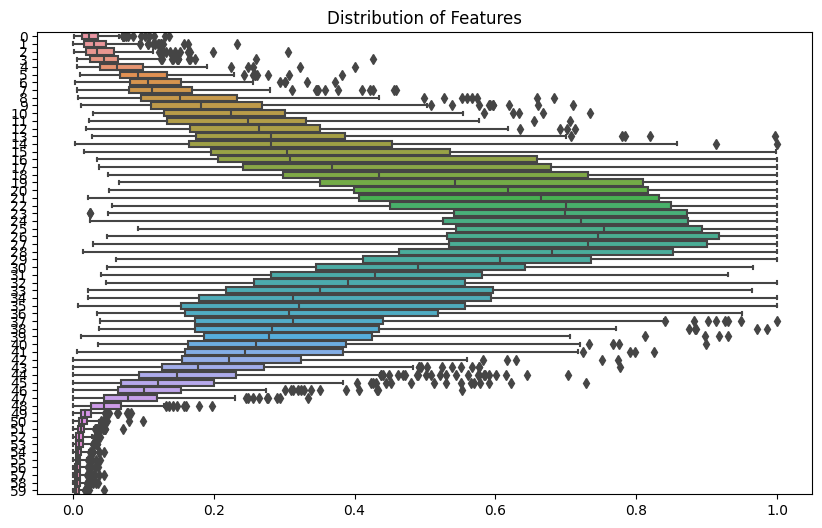

In [27]:
# Visualize the distribution of features
plt.figure(figsize=(10, 6))
sns.boxplot(data=sonar_data.iloc[:, :-1], orient="h")
plt.title("Distribution of Features")
plt.show()

In [28]:
# Exclude the target column before calculating correlations
correlation_data = sonar_data.drop(columns=60)  # Only numeric columns

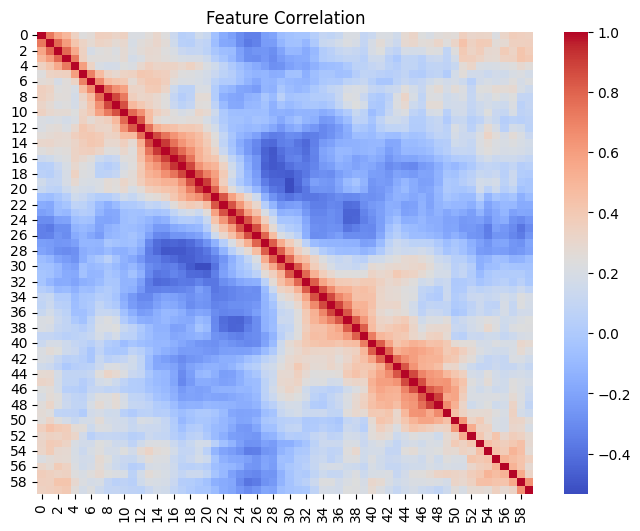

In [29]:
# Target correlation visualization
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation")
plt.show()

In [30]:
# Splitting features and labels
X = sonar_data.drop(columns=60, axis=1)
Y = sonar_data[60]

In [31]:
# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, stratify=Y, random_state=1)

In [32]:
# Pipeline for scaling and modeling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

In [33]:
# Model training
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('logreg', LogisticRegression())])

In [34]:
# Predictions
train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

In [35]:
# Accuracy scores
train_acc = accuracy_score(Y_train, train_pred)
test_acc = accuracy_score(Y_test, test_pred)
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

Training Accuracy: 0.92
Testing Accuracy: 0.76


In [36]:
# Classification report
print("\nClassification Report:")
print(classification_report(Y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

           M       0.75      0.82      0.78        11
           R       0.78      0.70      0.74        10

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.76      0.76      0.76        21



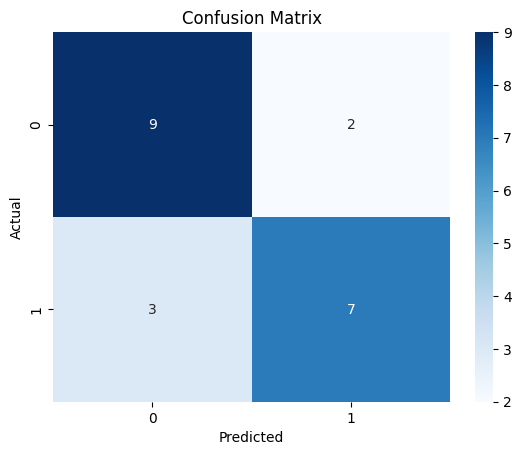

In [37]:
# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, test_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

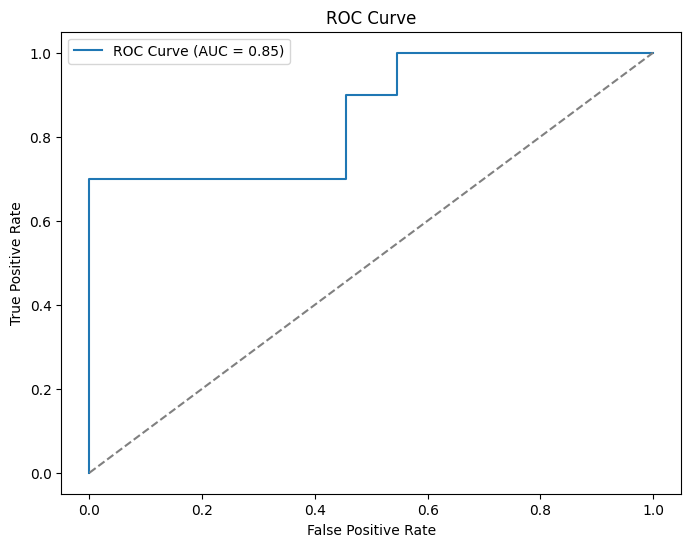

In [38]:
# ROC-AUC Curve
Y_test_binary = np.where(Y_test == 'R', 1, 0)
test_pred_proba = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test_binary, test_pred_proba)
roc_auc = roc_auc_score(Y_test_binary, test_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
# Save model
joblib.dump(pipeline, "logistic_model.pkl")

# Load and test model
loaded_model = joblib.load("logistic_model.pkl")
input_data = (0.0307,0.0523,0.0653,0.0521,0.0611,0.0577,0.0665,0.0664,0.1460,0.2792,0.3877,0.4992,0.4981,0.4972,0.5607,0.7339,0.8230,0.9173,0.9975,0.9911,0.8240,0.6498,0.5980,0.4862,0.3150,0.1543,0.0989,0.0284,0.1008,0.2636,0.2694,0.2930,0.2925,0.3998,0.3660,0.3172,0.4609,0.4374,0.1820,0.3376,0.6202,0.4448,0.1863,0.1420,0.0589,0.0576,0.0672,0.0269,0.0245,0.0190,0.0063,0.0321,0.0189,0.0137,0.0277,0.0152,0.0052,0.0121,0.0124,0.0055)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)
prediction = loaded_model.predict(input_data_as_numpy_array)
print(f"Prediction: {'Rock' if prediction[0] == 'R' else 'Mine'}")

Prediction: Mine
